<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E7%89%B9%E5%BE%B5%E7%AF%A9%E9%81%B8%E5%BE%8C%E5%BB%BA%E6%A8%A1_%E5%B0%8D%E9%A6%AC%E5%BC%8F%E8%B7%9D%E9%9B%A2%E7%95%B0%E5%B8%B8%E5%80%BC%E5%BB%BA%E6%A8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import joblib
features = joblib.load('/content/features1.pkl')
features

['MLUT4_AIA792101B',
 'MLUT4_TE-252D',
 'MLUT4_AT-232A',
 'MLUT4_FIC-231B',
 'MLUT4_TE-252F',
 'MLUT4_FIC-231C',
 'MLUT4_PIC-233',
 'MLUT4_TE-252I',
 '前爐SOx濃度',
 'MLUT4_TE-252G',
 '鈣硫比',
 'MLUT4_IT-E7925B',
 'MLUT4_FIC-231A',
 'MLUT4_FIC-233',
 'MLUT4_ZT-232',
 'MLUT4_FT-792020',
 'MLUT4_TE-251A',
 'MLUT4_IT-E7925A',
 'MLUT4_PDT-232',
 'MLUT4_TE-251H',
 'MLUT4_TE-251G',
 'MLUT4_FQ-205',
 'MLUT4_TE-252E',
 'MLUT4_TE-251F',
 'MLUT4_TE-251D']

In [3]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df

Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,6.800000,67.034424,151.208024,9.623605,8.619934,8.619934,20.605973,0.000000,17.456094,...,876.984866,845.297084,845.703201,876.997523,59.200001,15.000000,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,6.800000,66.662524,150.811453,9.616252,8.147002,8.147002,20.181020,0.000000,17.449118,...,875.326466,846.587071,844.102850,877.381060,59.200001,15.000000,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,6.800000,64.320729,151.708113,9.608899,8.247992,8.247992,20.200619,0.000000,17.442142,...,875.675699,845.374599,843.500123,877.897600,59.200001,15.000000,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,6.801543,64.840762,151.283528,9.600898,7.605820,7.605820,20.220218,0.000000,17.571883,...,875.435828,845.100450,842.910508,874.888616,59.200001,15.000000,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,6.819977,64.390831,150.994896,9.581994,6.110485,6.110485,20.549012,0.000000,17.339679,...,875.245400,846.058978,844.200021,878.416710,59.200001,15.000000,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.842200,...,916.635699,889.885541,906.016252,870.865216,100.000000,26.103367,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,914.065610,889.042164,904.255862,869.007829,100.000000,26.093265,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,913.978871,890.439554,903.442876,867.712970,100.000000,26.100000,0.949882,0.910708,2088.339754,3.928170


In [4]:
y_col = ['DeSOx_1st']

In [5]:
df[features+y_col]

,MLUT4_AIA792101B,MLUT4_TE-252D,MLUT4_AT-232A,MLUT4_FIC-231B,MLUT4_TE-252F,MLUT4_FIC-231C,MLUT4_PIC-233,MLUT4_TE-252I,前爐SOx濃度,MLUT4_TE-252G,...,MLUT4_TE-251A,MLUT4_IT-E7925A,MLUT4_PDT-232,MLUT4_TE-251H,MLUT4_TE-251G,MLUT4_FQ-205,MLUT4_TE-252E,MLUT4_TE-251F,MLUT4_TE-251D,DeSOx_1st
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,6.800000,861.535652,151.208024,0.000000,876.984866,17.456094,971.286903,876.997523,2230.093232,845.297084,...,852.845578,13.302897,78.370626,848.081753,865.547033,357.373726,862.146116,851.281979,813.975526,0.969941
2024-01-01 00:05:00,6.800000,860.299612,150.811453,0.000000,875.326466,17.449118,969.395192,877.381060,2220.527929,846.587071,...,852.731596,13.276501,79.258313,846.739478,865.893512,356.975651,861.105258,851.523215,812.894222,0.969979
2024-01-01 00:10:00,6.800000,858.073290,151.708113,0.000000,875.675699,17.442142,969.959118,877.897600,2237.129686,845.374599,...,852.299359,13.300000,77.719304,845.910855,864.633097,355.650485,858.741062,852.383846,811.565542,0.971249
2024-01-01 00:15:00,6.801543,858.422111,151.283528,0.000000,875.435828,17.571883,971.875751,874.888616,2227.895501,845.100450,...,851.998446,13.300000,78.297800,846.557376,865.266945,356.219519,859.359258,852.210935,811.676989,0.970896
2024-01-01 00:20:00,6.819977,859.316649,150.994896,0.000000,875.245400,17.339679,971.082502,878.416710,2211.052236,846.058978,...,853.103167,13.275966,78.501901,847.392939,865.855770,357.409226,860.513811,852.420520,812.232824,0.970878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,5.140339,928.560012,209.520746,11.854892,916.635699,12.842200,954.066222,870.865216,2082.274527,889.885541,...,873.659289,12.774718,55.084016,896.906039,903.296004,307.745677,913.593762,867.791546,917.846554,0.945172
2024-09-15 23:40:00,5.166336,926.909370,208.177318,11.862273,914.065610,12.823741,956.169561,869.007829,2071.948976,889.042164,...,873.036276,12.769719,54.970461,893.734669,903.055527,308.234169,911.424740,865.914718,915.550251,0.948517
2024-09-15 23:45:00,5.225976,926.152206,211.564232,11.880556,913.978871,12.842696,958.502714,867.712970,2088.339754,890.439554,...,873.562550,12.744950,54.838819,894.238092,903.755380,304.988863,911.234664,866.209358,915.649930,0.949882


# 刪除離群值

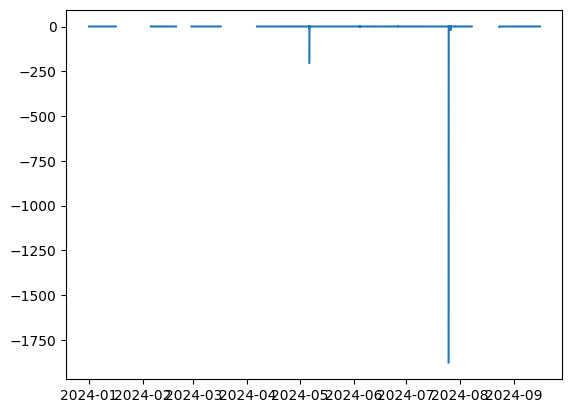

In [6]:
import matplotlib.pyplot as plt
plt.plot(df.index,df['DeSOx_1st'])
plt.show()

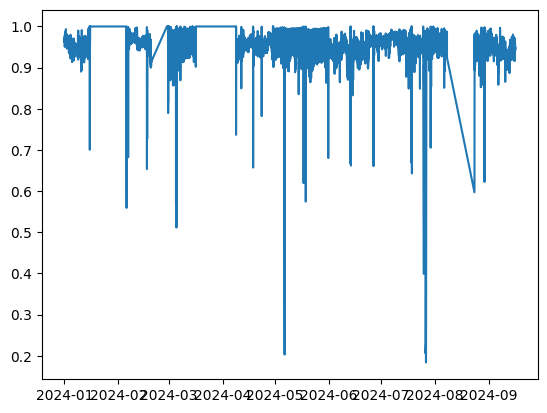

In [7]:
data = df[df['DeSOx_1st']>0]
plt.plot(data.index,data['DeSOx_1st'])
plt.show()

# 馬氏距離刪除離群值

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import chi2

def del_outliers_mahalanobis(df):
  mean_vec = df.mean().values
  cov_matrix = np.cov(df.values, rowvar=False)
  inv_cov_matrix = np.linalg.inv(cov_matrix)

  # Step 2: 計算每筆資料的馬氏距離
  def mahalanobis(x, mean, inv_cov):
      diff = x - mean
      return np.sqrt(diff.T @ inv_cov @ diff)

  # 計算所有樣本的距離
  distances = df.apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)

  # Step 3: 決定閾值，例如卡方分布下95%置信區間的臨界值（自由度=2因為是兩欄）
  threshold = np.sqrt(chi2.ppf(0.99, df=2))

  # Step 4: 過濾掉離群樣本
  df_clean = df[distances < threshold]

  # 如果你想看哪些是離群值
  outliers = df[distances >= threshold]

  return outliers

In [12]:
outliers_list = []
for i in features:
  outliers = data.loc[del_outliers_mahalanobis(data[[i,'DeSOx_1st']]).index,:]
  outliers_list.append(outliers)
outliers_list

[                     MLUT4_AIA792101A  MLUT4_AIA792101B  MLUT4_AIC-232B  \
 datetime                                                                  
 2024-01-15 15:55:00          4.202269          4.072430      625.101090   
 2024-01-15 16:00:00          4.312737          4.206268      654.340051   
 2024-01-16 07:35:00         15.201653         11.533934        0.000000   
 2024-01-16 07:40:00         15.656832         12.955273        0.000000   
 2024-01-16 07:45:00         17.504109         18.261986        0.000000   
 ...                               ...               ...             ...   
 2024-08-28 20:25:00          9.050879         11.679322       25.304952   
 2024-08-29 09:15:00          7.179814          6.444935      378.957074   
 2024-08-29 09:20:00          7.151238          6.495803      663.960823   
 2024-09-10 07:00:00         11.762425          7.093845      158.663958   
 2024-09-13 14:00:00         18.418554         17.960737      116.337407   
 
          

In [14]:
import pandas as pd
outliers_df = pd.concat(outliers_list)
outliers_df

,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-15 15:55:00,4.202269,4.072430,625.101090,237.094911,7.291879,12.982626,12.991224,15.505445,12.796663,14.123067,...,885.171986,866.350522,880.682639,870.164275,52.099998,19.883675,0.710510,0.979231,2159.316995,2.031480
2024-01-15 16:00:00,4.312737,4.206268,654.340051,237.241954,7.601567,7.509983,7.509866,15.513180,12.775104,14.175211,...,882.732820,862.444031,876.330503,864.999907,52.099998,19.882633,0.700395,0.988523,2184.012153,1.938794
2024-01-16 07:35:00,15.201653,11.533934,0.000000,0.194617,16.154572,7.021524,7.021524,0.005480,0.059033,9.972308,...,804.786719,734.932447,683.462896,624.307013,45.367854,19.900000,1.000000,NaN,585.896679,9.591287
2024-01-16 07:40:00,15.656832,12.955273,0.000000,0.334862,17.163638,4.000000,4.000000,0.005375,0.058195,5.401289,...,770.319824,697.354582,648.953493,601.252291,45.000000,19.900000,1.000000,NaN,448.856098,10.876252
2024-01-16 07:45:00,17.504109,18.261986,0.000000,1.420142,19.936356,4.002135,4.002135,0.005270,0.057357,0.011904,...,631.182544,626.296303,587.621644,567.148949,45.000000,19.900000,1.000000,NaN,166.235454,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 16:30:00,10.505846,8.139989,30.885959,132.809346,12.525350,13.127749,13.127749,7.630927,0.000000,7.746124,...,811.998337,784.032113,745.351237,685.492928,99.731990,16.138327,0.952670,0.574961,652.562195,5.335537
2024-08-23 16:35:00,10.336531,7.910145,22.262865,152.371747,12.396927,8.857276,8.857276,8.604703,0.000000,8.543452,...,830.191933,798.890690,761.868457,679.892378,99.707561,16.168667,0.969756,0.602150,736.102628,4.706648
2024-08-27 06:50:00,8.327531,4.199061,282.860034,141.335728,10.897896,13.600000,13.600000,0.038124,15.160363,13.375507,...,937.530413,903.767914,884.477240,839.596720,99.800003,19.920200,0.852419,0.951920,1916.637319,5.200225


In [16]:
data = outliers_df

# 標準化

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data.loc[:,features] = scaler.fit_transform(data.loc[:,features])
data

,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-15 15:55:00,4.202269,-1.037991,625.101090,1.622866,7.291879,12.982626,12.991224,0.742657,0.794429,0.645657,...,0.453200,0.657362,880.682639,0.499378,52.099998,-0.208616,0.710510,0.979231,0.017447,-0.057744
2024-01-15 16:00:00,4.312737,-0.999135,654.340051,1.624736,7.601567,7.509983,7.509866,0.743767,0.791028,0.653544,...,0.430786,0.620445,876.330503,0.449871,52.099998,-0.208743,0.700395,0.988523,0.022218,-0.057761
2024-01-16 07:35:00,15.201653,1.128205,0.000000,-1.390720,16.154572,7.021524,7.021524,-1.480855,-1.214657,0.017890,...,-0.285455,-0.584547,683.462896,-1.857506,45.367854,-0.206613,1.000000,NaN,-0.286550,-0.056349
2024-01-16 07:40:00,15.656832,1.540843,0.000000,-1.388936,17.163638,4.000000,4.000000,-1.480870,-1.214789,-0.673438,...,-0.602170,-0.939660,648.953493,-2.078517,45.000000,-0.206613,1.000000,NaN,-0.313028,-0.056112
2024-01-16 07:45:00,17.504109,3.081468,0.000000,-1.375130,19.936356,4.002135,4.002135,-1.480886,-1.214921,-1.488537,...,-1.880693,-1.611164,587.621644,-2.405445,45.000000,-0.206613,1.000000,NaN,-0.367632,-0.058118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-23 16:30:00,10.505846,0.142888,30.885959,0.296259,12.525350,13.127749,13.127749,-0.386964,-1.223968,-0.318801,...,-0.219188,-0.120552,745.351237,-1.270954,99.731990,-0.668005,0.952670,0.574961,-0.273670,-0.057134
2024-08-23 16:35:00,10.336531,0.076160,22.262865,0.545111,12.396927,8.857276,8.857276,-0.247273,-1.223968,-0.198212,...,-0.052009,0.019862,761.868457,-1.324643,99.707561,-0.664283,0.969756,0.602150,-0.257529,-0.057250
2024-08-27 06:50:00,8.327531,-1.001228,282.860034,0.404722,10.897896,13.600000,13.600000,-1.476172,1.167251,0.532595,...,0.934318,1.010958,884.477240,0.206346,99.800003,-0.204136,0.852419,0.951920,-0.029441,-0.057159


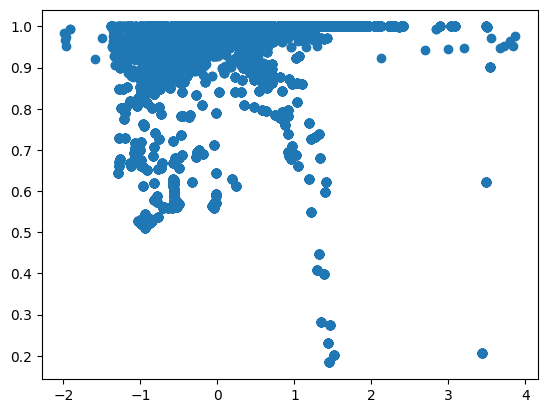

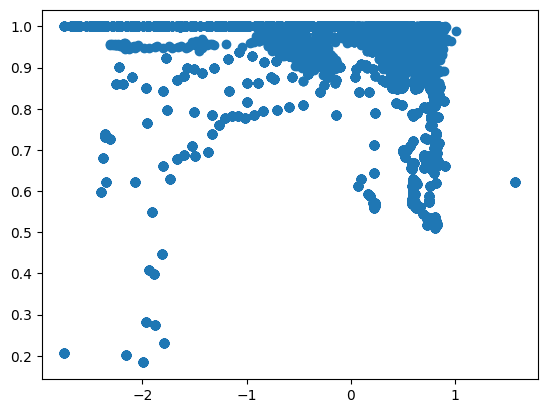

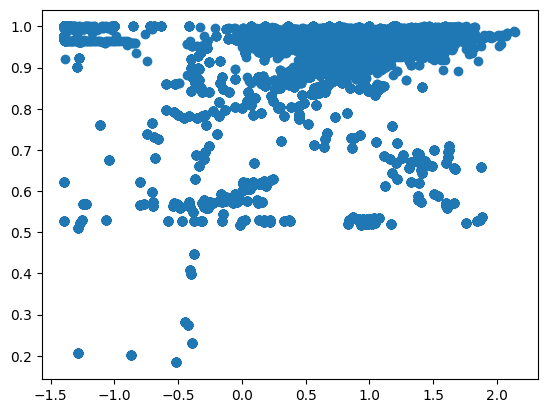

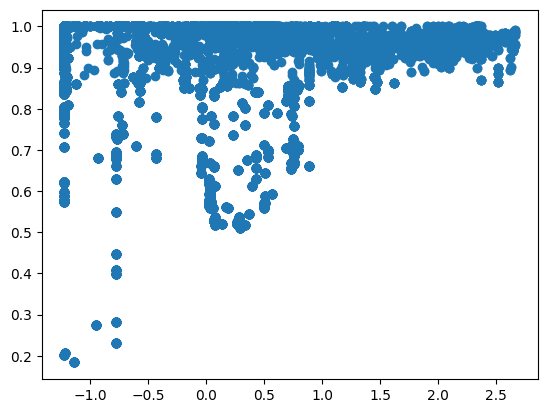

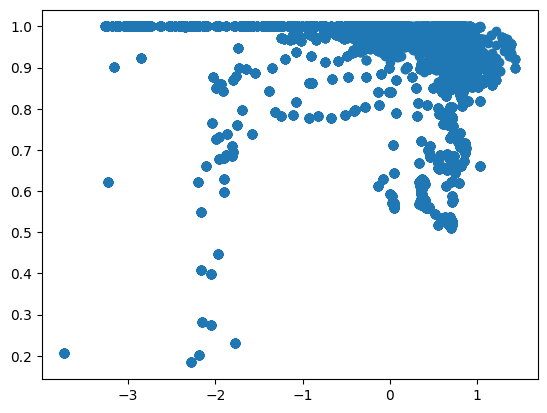

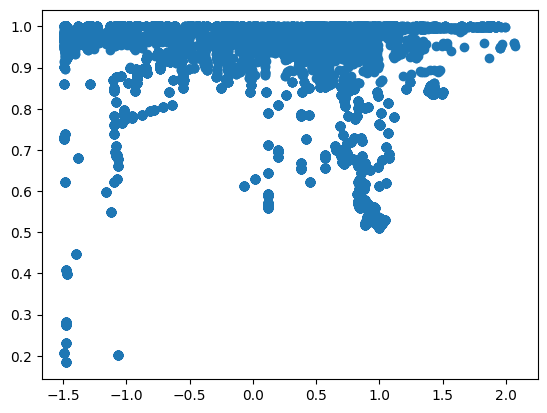

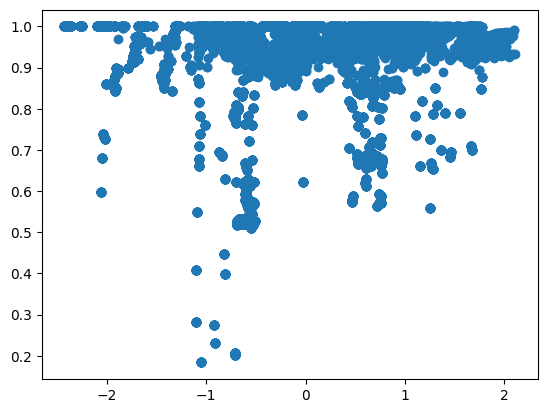

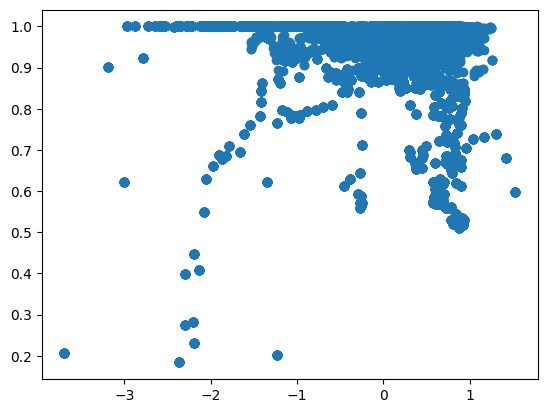

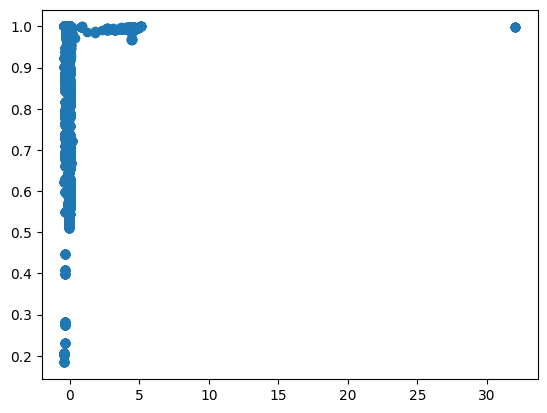

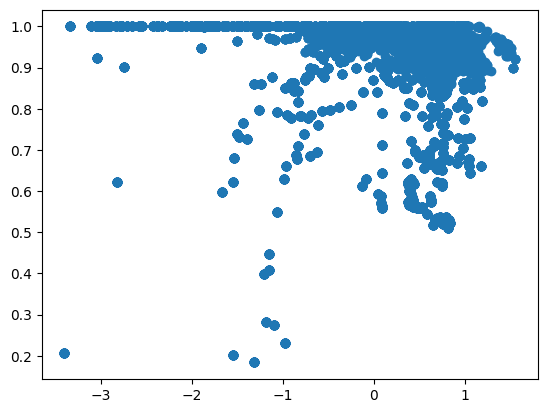

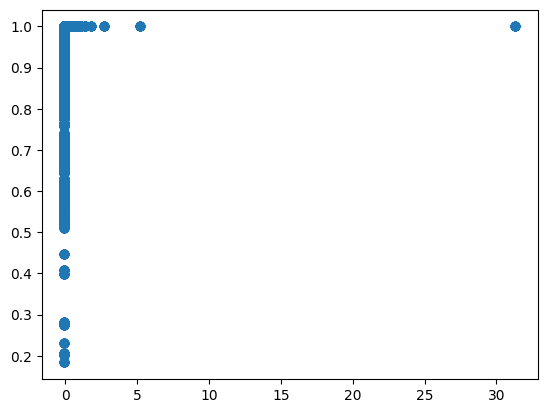

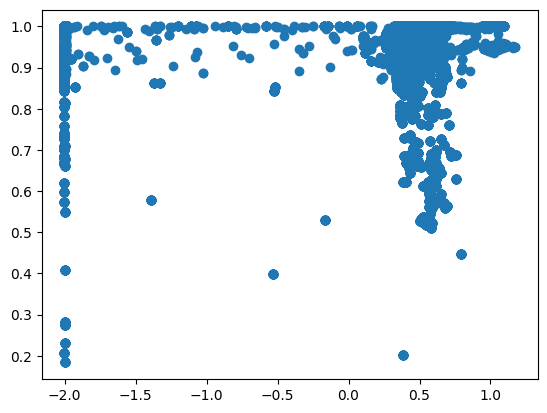

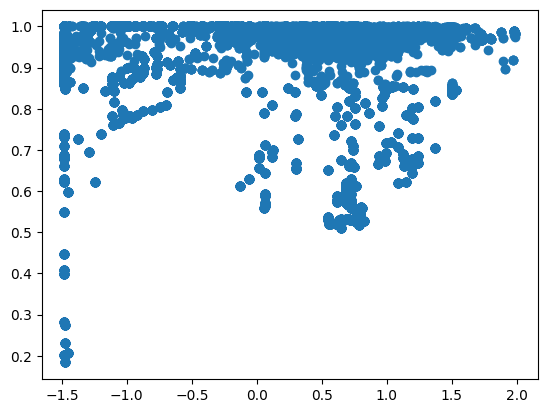

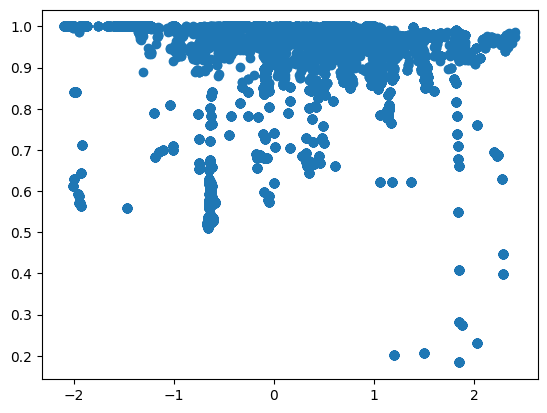

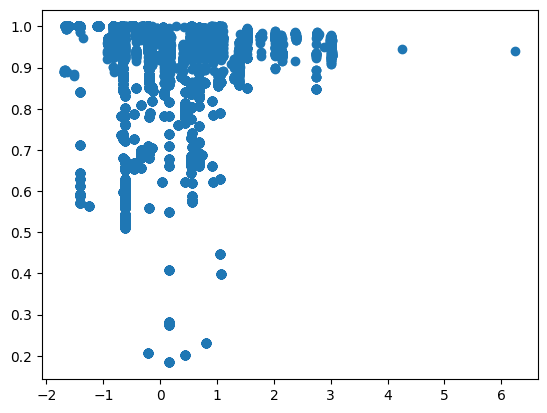

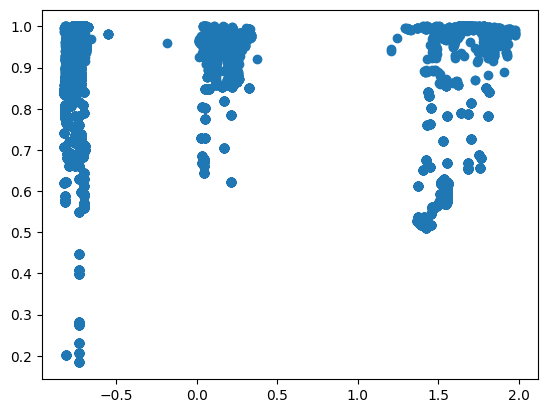

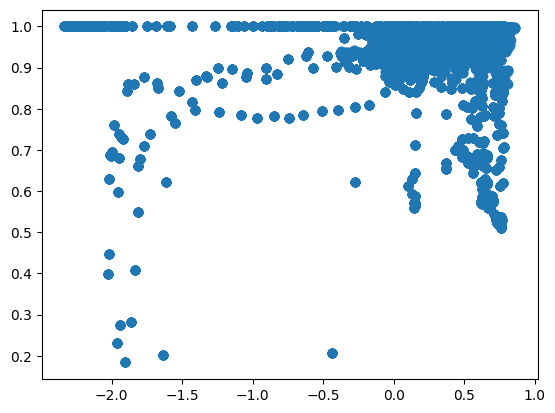

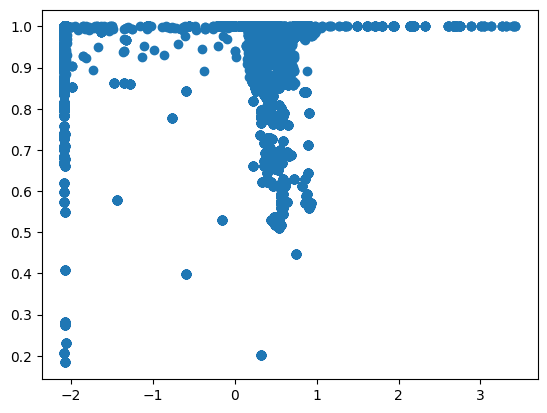

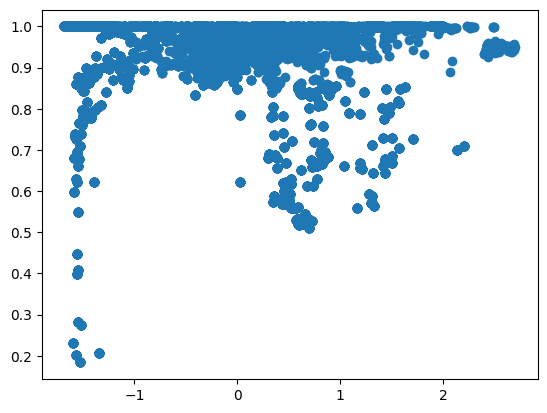

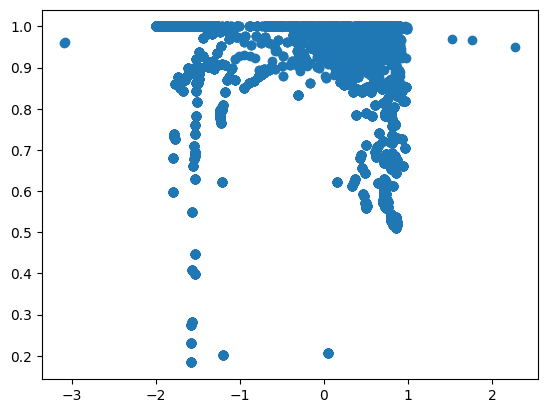

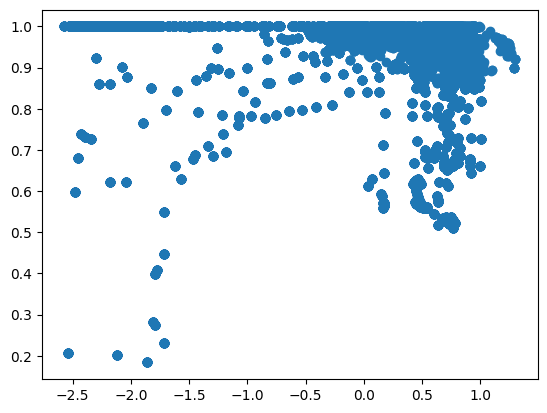

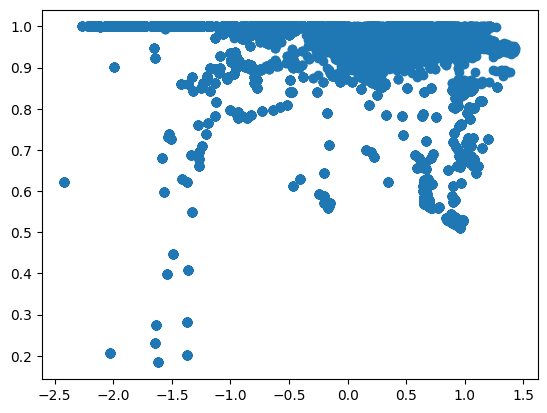

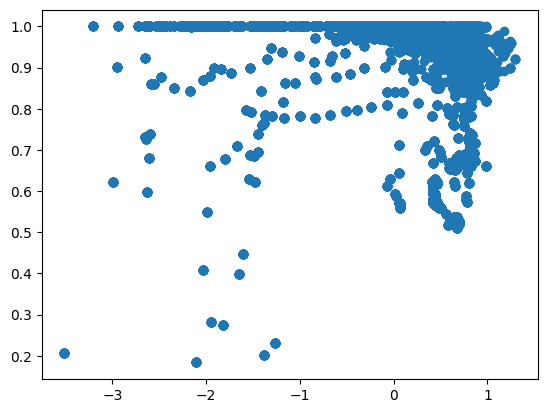

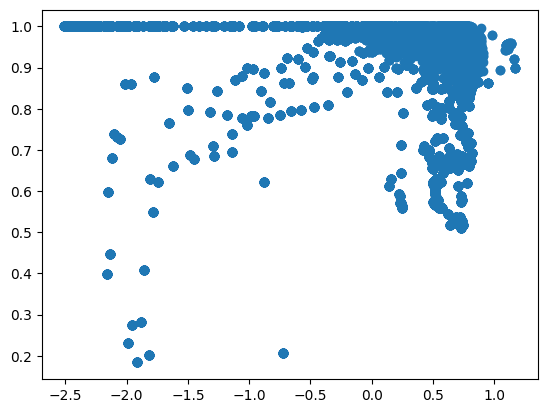

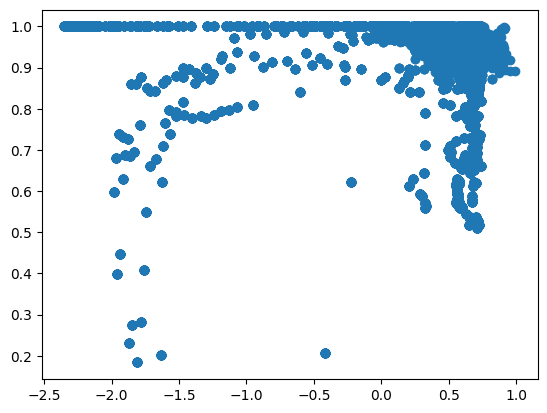

In [18]:
for i in features:
  plt.scatter(data[i],data['DeSOx_1st'])
  plt.show()

# 線性回歸

In [19]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

X,Y = data[features],data['DeSOx_1st']

# 2. 資料切分：訓練 80% / 測試 20%
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 預測
y_pred = model.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_reg = res
res_reg

,R2,RMSE,MAPE
0,0.559461,0.118239,12.268015


# Ridge 回歸

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 切分資料為訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 Ridge 回歸模型
ridge = Ridge(alpha=1.0)  # 可嘗試不同的 alpha，例如 0.1, 1, 10
ridge.fit(X_train, y_train)

# 4. 預測
y_pred = ridge.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ridge = res
res_ridge


,R2,RMSE,MAPE
0,0.559468,0.118239,12.268188


# Lasso 回歸

In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 Lasso 模型並訓練
lasso = Lasso(alpha=0.1)  # alpha 越大，壓縮越強，更多係數會變 0
lasso.fit(X_train, y_train)

# 4. 預測
y_pred = lasso.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_lasso = res
res_lasso


,R2,RMSE,MAPE
0,-0.00013,0.178155,22.131459


In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 ElasticNet 模型並訓練
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 表示 L1:L2 = 1:1
elastic_net.fit(X_train, y_train)

# 4. 預測
y_pred = elastic_net.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ElasticNet = res
res_ElasticNet


,R2,RMSE,MAPE
0,0.149352,0.164303,20.428032


In [23]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 PLS 模型（選擇主成分數目）
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

# 4. 預測
y_pred = pls.predict(X_test).ravel()  # .ravel() 將輸出轉成一維陣列

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_PLS = res
res_PLS


,R2,RMSE,MAPE
0,0.383347,0.139891,15.318196


In [24]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=42)
n_estimators = 100
for i in tqdm(range(1, n_estimators + 1)):
    rf.set_params(n_estimators=i)
    rf.fit(X_train, y_train)

# 4. 預測
y_pred = rf.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_rf = res
res_rf


100%|██████████| 100/100 [00:26<00:00,  3.70it/s]


,R2,RMSE,MAPE
0,0.996696,0.01024,0.155095


In [25]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 XGBoost 回歸模型
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# 4. 預測
y_pred = xgb.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_xgb = res
res_xgb


,R2,RMSE,MAPE
0,0.995892,0.011418,0.294941


In [26]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. 建立並訓練 SVR 模型
svr = SVR()
svr.fit(X_train,y_train)

# 5. 預測（記得反標準化）
y_pred = svr.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_svr = res
res_svr


,R2,RMSE,MAPE
0,0.854077,0.068051,7.879119


In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np

# 切分資料
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 轉成Tensor
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# 2. 定義 MLP 模型
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=len(features))

# 3. 損失函數與優化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 訓練迴圈
n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

# 5. 測試與評估
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t).view(-1).numpy()

r2 = r2_score(y_test, y_pred_t)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
mape = mean_absolute_percentage_error(y_test, y_pred_t)

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_mlp = res
res_mlp


Epoch [5/300], Loss: 0.2688
Epoch [10/300], Loss: 0.0919
Epoch [15/300], Loss: 0.0365
Epoch [20/300], Loss: 0.0246
Epoch [25/300], Loss: 0.0274
Epoch [30/300], Loss: 0.0228
Epoch [35/300], Loss: 0.0164
Epoch [40/300], Loss: 0.0127
Epoch [45/300], Loss: 0.0113
Epoch [50/300], Loss: 0.0104
Epoch [55/300], Loss: 0.0096
Epoch [60/300], Loss: 0.0087
Epoch [65/300], Loss: 0.0081
Epoch [70/300], Loss: 0.0074
Epoch [75/300], Loss: 0.0070
Epoch [80/300], Loss: 0.0065
Epoch [85/300], Loss: 0.0062
Epoch [90/300], Loss: 0.0059
Epoch [95/300], Loss: 0.0056
Epoch [100/300], Loss: 0.0053
Epoch [105/300], Loss: 0.0050
Epoch [110/300], Loss: 0.0048
Epoch [115/300], Loss: 0.0046
Epoch [120/300], Loss: 0.0044
Epoch [125/300], Loss: 0.0042
Epoch [130/300], Loss: 0.0040
Epoch [135/300], Loss: 0.0039
Epoch [140/300], Loss: 0.0038
Epoch [145/300], Loss: 0.0036
Epoch [150/300], Loss: 0.0035
Epoch [155/300], Loss: 0.0034
Epoch [160/300], Loss: 0.0033
Epoch [165/300], Loss: 0.0032
Epoch [170/300], Loss: 0.0031


,R2,RMSE,MAPE
0,0.933132,0.046066,0.039813


In [28]:
res = pd.concat([res_reg,res_ridge,res_lasso,res_ElasticNet,res_PLS,res_rf,res_xgb,res_svr,res_mlp])
res.index = ['reg','ridge','lasso','elastic','PLS','rf','xgb','svr','mlp']
res

,R2,RMSE,MAPE
reg,0.559461,0.118239,12.268015
ridge,0.559468,0.118239,12.268188
lasso,-0.000130,0.178155,22.131459
elastic,0.149352,0.164303,20.428032
PLS,0.383347,0.139891,15.318196
rf,0.996696,0.010240,0.155095
xgb,0.995892,0.011418,0.294941
svr,0.854077,0.068051,7.879119
mlp,0.933132,0.046066,0.039813


<ipython-input-29-3284107390>:12: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 29200 (\N{CJK UNIFIED IDEOGRAPH-7210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 28611 (\N{CJK UNIFIED IDEOGRAPH-6FC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 37411 (\N{CJK UNIFIED IDEOGRAPH-9223}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 30827 (\N{CJK UNIFIED IDEOGRAPH-786B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-29-3284107390>:12: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaV

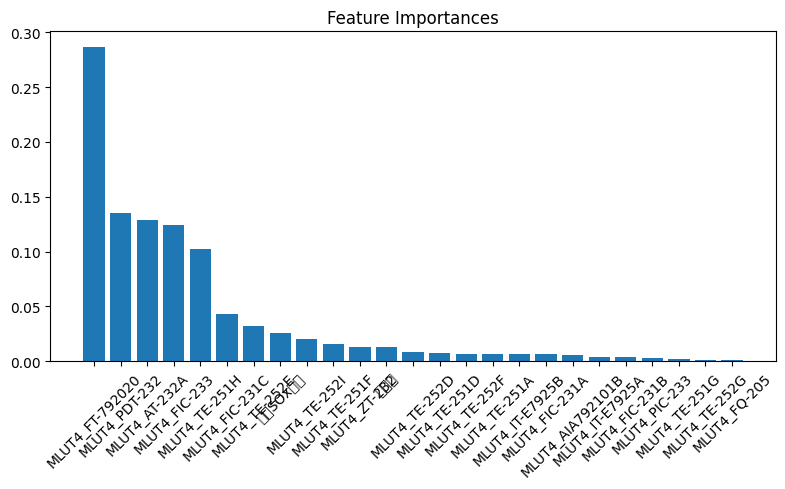

In [29]:
import matplotlib.pyplot as plt

# 排序特徵重要度
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 畫圖
plt.figure(figsize=(8, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


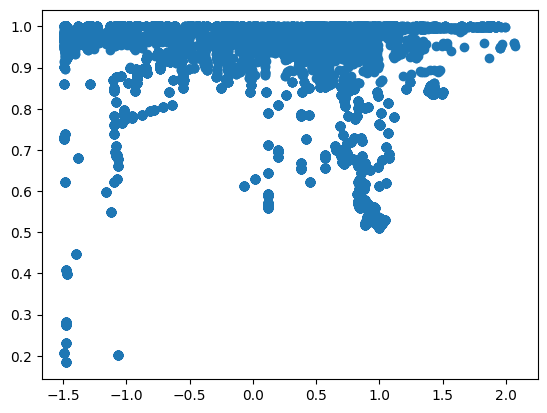

In [30]:
plt.scatter(data['MLUT4_FIC-231C'],data['DeSOx_1st'])